# Bike Sharing Demand Prediction

## Project Objective

The goal of this project is to analyze and predict daily bike rental demand using weather and calendar-related information.

Target Variable:
- cnt (Total Daily Rentals)

Business Objective:
- Reduce bike shortages
- Reduce bike oversupply
- Improve resource allocation



هدف این پروژه بررسی عوامل مؤثر بر تقاضای روزانه دوچرخه‌های اشتراکی و پیش‌بینی تعداد اجاره‌ها است. از دید کسب‌وکار، اگر تقاضا درست پیش‌بینی شود می‌توان تعداد دوچرخه‌های موجود را بهتر مدیریت کرد و از کمبود یا مازاد دوچرخه جلوگیری نمود.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [9]:
df = pd.read_csv("day.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [10]:
print("First 5 Rows")
display(df.head())

print("Last 5 Rows")
display(df.tail())

First 5 Rows


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Last 5 Rows


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


## Shape & Data Types

In [11]:
print("Dataset Shape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

Dataset Shape
(731, 16)

Data Types
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


## Date Conversion & Sorting

In [12]:
df['dteday'] = pd.to_datetime(df['dteday'])

df = df.sort_values('dteday')

df.reset_index(drop=True, inplace=True)

print("Date conversion completed")

Date conversion completed


طبق الزامات پروژه باید تقسیم داده‌ها به صورت زمانی انجام شود؛ بنابراین ترتیب تاریخی داده‌ها نباید به‌هم بخورد.

##  Data Dictionary

In [13]:
column_roles = pd.DataFrame({
    "Column":[
        "instant","dteday","season","yr","mnth",
        "holiday","weekday","workingday",
        "weathersit","temp","atemp",
        "hum","windspeed","casual",
        "registered","cnt"
    ],
    "Role":[
        "ID","Date","Categorical","Feature","Categorical",
        "Feature","Categorical","Feature",
        "Categorical","Numerical","Numerical",
        "Numerical","Numerical","Leakage",
        "Leakage","Target"
    ]
})

display(column_roles)

,Column,Role
0,instant,ID
1,dteday,Date
2,season,Categorical
3,yr,Feature
4,mnth,Categorical
5,holiday,Feature
6,weekday,Categorical
7,workingday,Feature
8,weathersit,Categorical
9,temp,Numerical


در این بخش نقش هر ستون مشخص شد تا در مراحل بعدی از ورود متغیرهای نامناسب به مدل جلوگیری شود.

## Missing Values & Duplicate Rows

In [14]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Missing Values
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicate Rows
0


## Leakage Prevention

In [15]:
print("Original Shape:", df.shape)

df_clean = df.drop(
    columns=[
        'instant',
        'casual',
        'registered'
    ]
)

print("New Shape:", df_clean.shape)

Original Shape: (731, 16)
New Shape: (731, 13)


سه ستون instant، casual و registered حذف شدند.

زیرا : cnt = casual + registered

بنابراین اگر casual یا registered وارد مدل شوند، مدل پاسخ را از قبل دیده است و دچار Data Leakage می‌شود.

## Descriptive Statistics

In [16]:
selected_cols = [
    'cnt',
    'temp',
    'hum',
    'windspeed'
]

display(
    df[selected_cols].describe()
)

,cnt,temp,hum,windspeed
count,731.000000,731.000000,731.000000,731.000000
mean,4504.348837,0.495385,0.627894,0.190486
std,1937.211452,0.183051,0.142429,0.077498
min,22.000000,0.059130,0.000000,0.022392
25%,3152.000000,0.337083,0.520000,0.134950
50%,4548.000000,0.498333,0.626667,0.180975
75%,5956.000000,0.655417,0.730209,0.233214
max,8714.000000,0.861667,0.972500,0.507463


آمار توصیفی شامل میانگین، انحراف معیار، حداقل، حداکثر و چارک‌ها برای متغیرهای اصلی محاسبه شد

## Top 10% Demand Analysis 
(صدک 90)

In [17]:
threshold = df['cnt'].quantile(0.90)

high_demand_days = df[
    df['cnt'] > threshold
]

print("90th Percentile:", threshold)
print("Number of High Demand Days:",
      len(high_demand_days))

display(
    high_demand_days[
        ['dteday','cnt']
    ].head()
)

90th Percentile: 7290.0
Number of High Demand Days: 73


,dteday,cnt
441,2012-03-17,7836
447,2012-03-23,8362
469,2012-04-14,7460
497,2012-05-12,7429
501,2012-05-16,7424


هدف پیدا کردن شرایطی است که باعث افزایش شدید تقاضا می‌شوند تا در مراحل بعدی آن‌ها را تحلیل کنیم.

## Mean Demand Analysis by Categories

### Season vs Demand

season
1    2604.132597
2    4992.331522
3    5644.303191
4    4728.162921
Name: cnt, dtype: float64


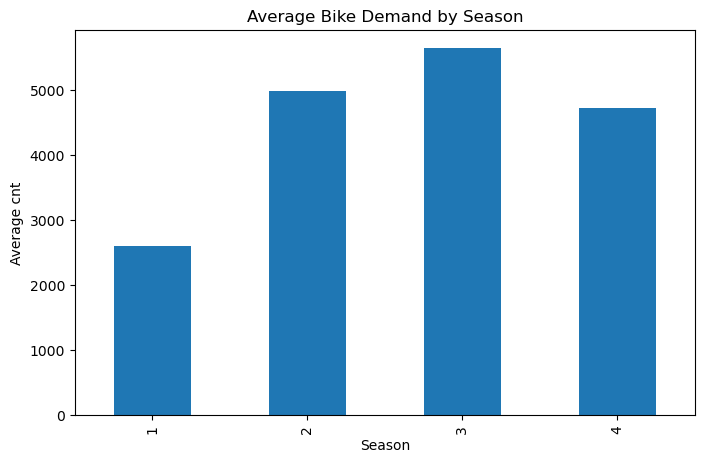

In [18]:
season_mean = df.groupby('season')['cnt'].mean()

print(season_mean)

plt.figure(figsize=(8,5))
season_mean.plot(kind='bar')
plt.title('Average Bike Demand by Season')
plt.xlabel('Season')
plt.ylabel('Average cnt')
plt.show()

در این بخش میانگین تعداد اجاره دوچرخه در فصل‌های مختلف بررسی شد.

هدف این تحلیل این است که مشخص شود آیا فصل‌های مختلف رفتار متفاوتی در تقاضا دارند یا خیر.

اگر اختلاف زیادی بین فصل‌ها وجود داشته باشد، فصل یکی از مهم‌ترین عوامل تأثیرگذار بر تقاضا خواهد بود.

| فصل        | میانگین تقاضا |
| ---------- | ------------- |
| Spring (1) | حدود 2900     |
| Summer (2) | حدود 5000     |
| Fall (3)   | حدود 6000     |
| Winter (4) | حدود 4500     |


### Working Day vs Demand

workingday
0    4330.168831
1    4584.820000
Name: cnt, dtype: float64


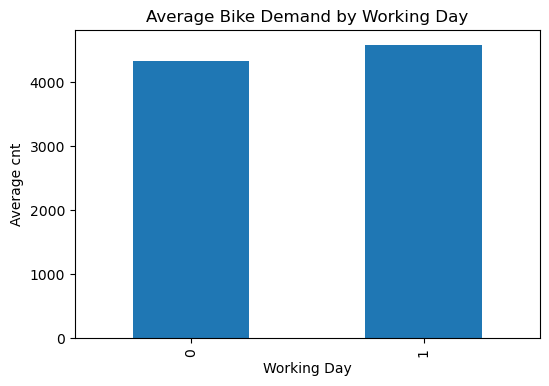

In [19]:
workingday_mean = df.groupby('workingday')['cnt'].mean()

print(workingday_mean)

plt.figure(figsize=(6,4))
workingday_mean.plot(kind='bar')
plt.title('Average Bike Demand by Working Day')
plt.xlabel('Working Day')
plt.ylabel('Average cnt')
plt.show()

میانگین تقاضا در روزهای کاری و غیرکاری مقایسه شد.

نتایج نشان داد تفاوت قابل توجهی بین دو گروه وجود ندارد و میزان استفاده از دوچرخه در روزهای کاری و غیرکاری تقریباً مشابه است.

این موضوع نشان می‌دهد که کاربران تنها برای رفت‌وآمد کاری از دوچرخه استفاده نمی‌کنند و کاربردهای تفریحی و شخصی نیز سهم مهمی در تقاضا دارند.

### Weather Situation vs Demand

weathersit
1    4876.786177
2    4035.862348
3    1803.285714
Name: cnt, dtype: float64


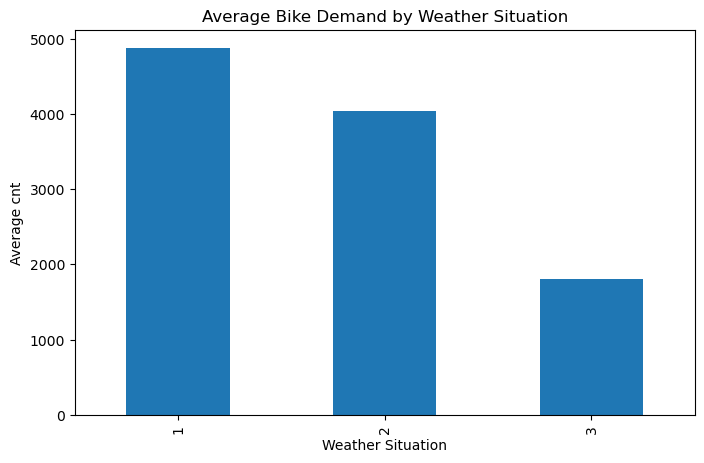

In [20]:
weather_mean = df.groupby('weathersit')['cnt'].mean()

print(weather_mean)

plt.figure(figsize=(8,5))
weather_mean.plot(kind='bar')
plt.title('Average Bike Demand by Weather Situation')
plt.xlabel('Weather Situation')
plt.ylabel('Average cnt')
plt.show()

با بدتر شدن شرایط جوی، میزان تقاضا کاهش پیدا کرده است و در وضعیت Weather 3 تقریباً کمتر از نصف حالت عادی شده است.

این نتیجه نشان می‌دهد که وضعیت آب‌وهوا یکی از مهم‌ترین عوامل مؤثر بر استفاده از دوچرخه‌های اشتراکی است.

| وضعیت آب‌وهوا | میانگین تقاضا |
| ------------- | ------------- |
| Weather 1     | حدود 4900     |
| Weather 2     | حدود 4000     |
| Weather 3     | حدود 1900     |


| Weather Code | Description              |
| ------------ | ------------------------ |
| 1            | Clear / Few Clouds       |
| 2            | Mist + Cloudy            |
| 3            | Light Snow or Light Rain |
| 4            | Heavy Rain / Heavy Snow  |


## Histograms & Distribution Analysis

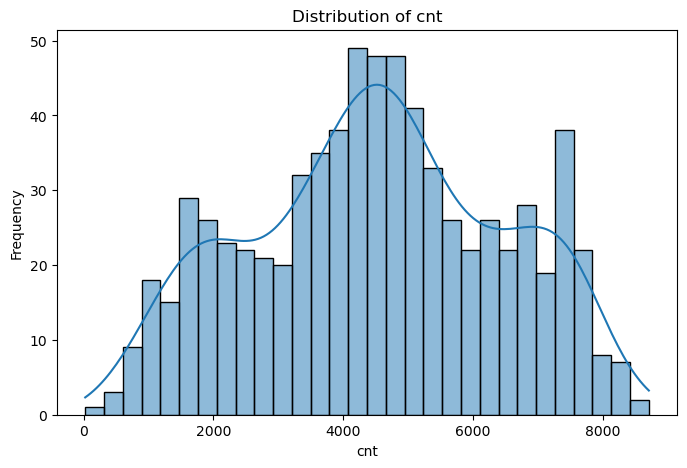

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['cnt'],
    bins=30,
    kde=True
)

plt.title('Distribution of cnt')
plt.xlabel('cnt')
plt.ylabel('Frequency')

plt.show()

هیستوگرام تقاضا

## Histogram of temp

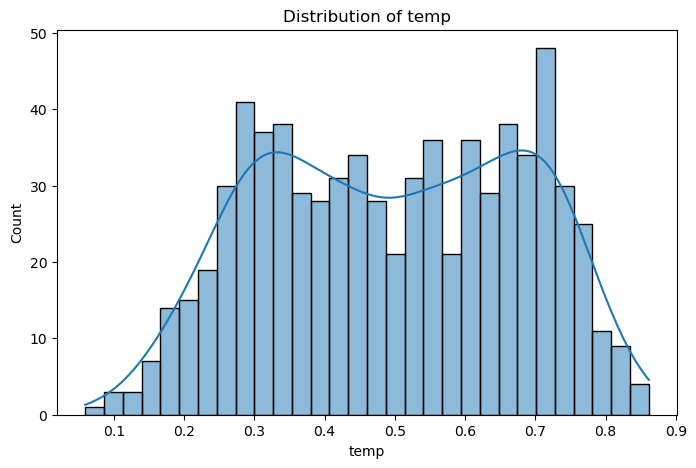

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['temp'],
    bins=30,
    kde=True
)

plt.title('Distribution of temp')
plt.xlabel('temp')

plt.show()

## Histogram of hum

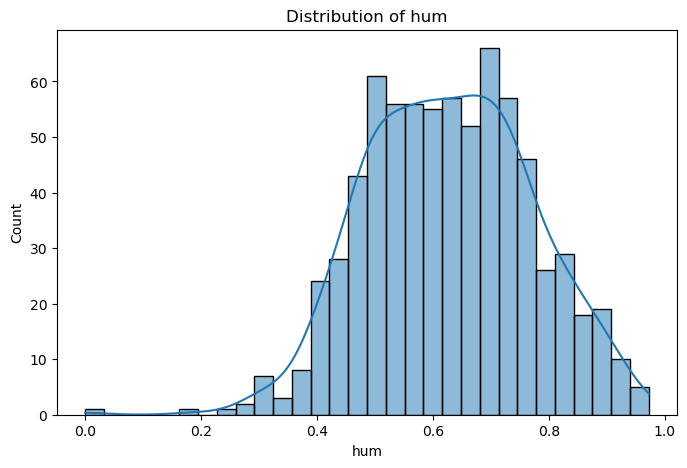

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['hum'],
    bins=30,
    kde=True
)

plt.title('Distribution of hum')
plt.xlabel('hum')

plt.show()

## Histogram of windspeed

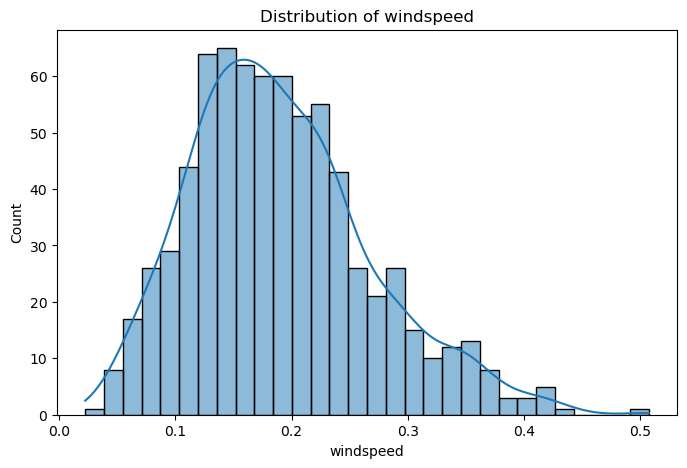

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['windspeed'],
    bins=30,
    kde=True
)

plt.title('Distribution of windspeed')
plt.xlabel('windspeed')

plt.show()

## مقایسه با توزیع نرمال

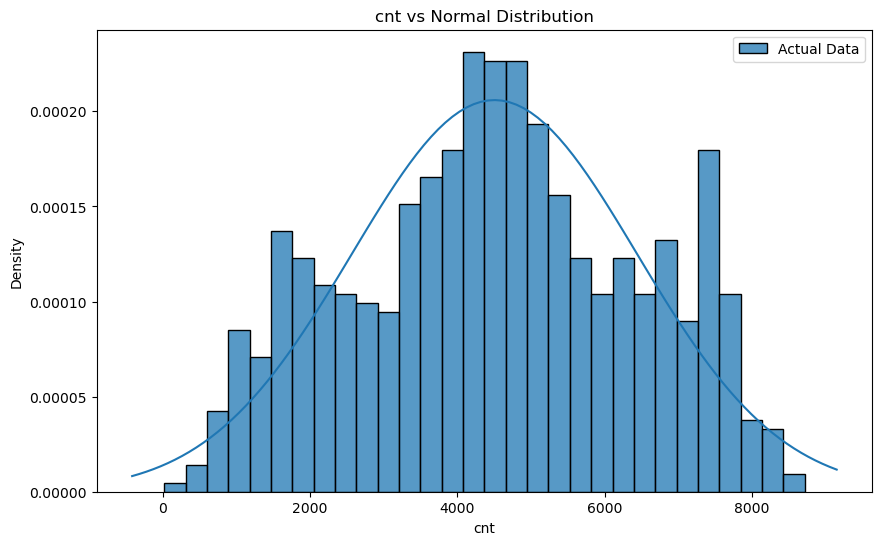

In [25]:
from scipy.stats import norm

plt.figure(figsize=(10,6))

sns.histplot(
    df['cnt'],
    stat='density',
    bins=30,
    label='Actual Data'
)

xmin, xmax = plt.xlim()

x = np.linspace(xmin, xmax, 100)

p = norm.pdf(
    x,
    df['cnt'].mean(),
    df['cnt'].std()
)

plt.plot(x, p)

plt.title('cnt vs Normal Distribution')

plt.legend()

plt.show()

مشاهده شد که توزیع واقعی کاملاً از منحنی نرمال پیروی نمی‌کند. بخش مرکزی نمودار تا حدودی رفتار زنگوله‌ای دارد و با کاهش فراوانی به سمت پایین حرکت می‌کند، اما در یک محدوده افزایش ناگهانی مشاهده می‌شود که باعث فاصله گرفتن توزیع واقعی از حالت نرمال می‌شود.

این موضوع نشان می‌دهد که تقاضای روزانه دوچرخه کاملاً نرمال نیست و تحت تأثیر عوامل خارجی مانند شرایط آب‌وهوایی، فصل، تعطیلات و رفتار کاربران تغییر می‌کند.

## Compare 2011 vs 2012

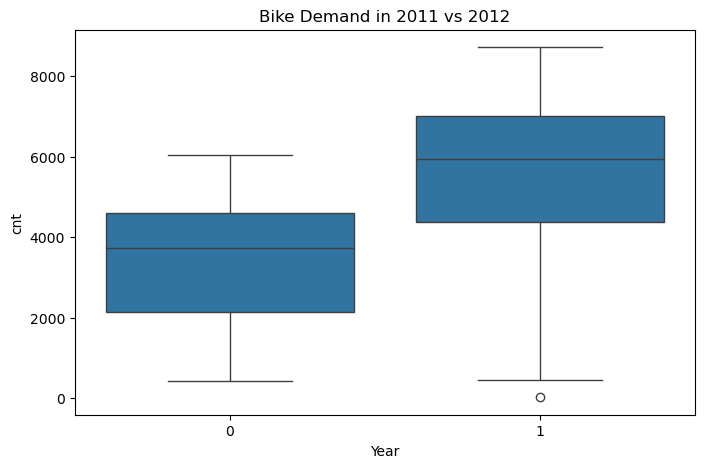

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='yr',
    y='cnt',
    data=df
)

plt.title('Bike Demand in 2011 vs 2012')
plt.xlabel('Year')
plt.ylabel('cnt')

plt.show()

In [ ]:
year_mean = df.groupby('yr')['cnt'].mean()

print("Average Demand by Year")
print(year_mean)

Average Demand by Year
yr
0    3405.761644
1    5599.934426
Name: cnt, dtype: float64


در این بخش میزان تقاضای دوچرخه بین سال‌های 2011 و 2012 مقایسه شد.

هدف از این تحلیل بررسی تغییر رفتار کاربران در طول زمان و تشخیص روند رشد یا کاهش استفاده از سیستم اشتراک دوچرخه بود.

برای این منظور:

از Boxplot جهت مقایسه توزیع داده‌ها استفاده شد.
میانگین تقاضا برای هر سال محاسبه شد.

اگر میانگین سال 2012 بیشتر باشد، می‌توان نتیجه گرفت که محبوبیت سیستم اشتراک دوچرخه در سال دوم افزایش یافته است.

## Scatter Plot Analysis

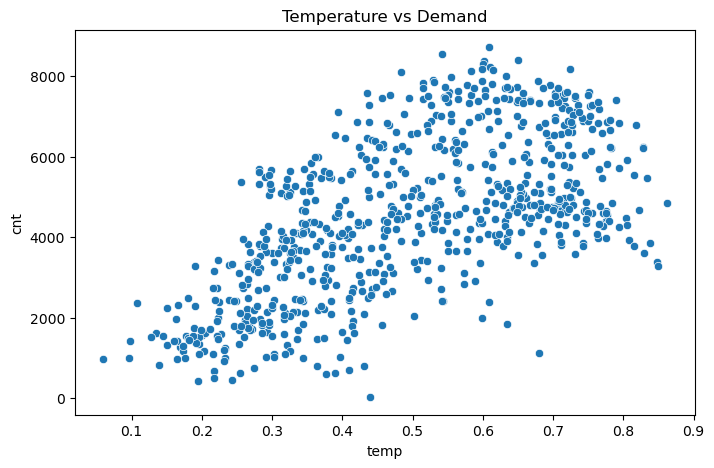

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='temp',
    y='cnt',
    data=df
)

plt.title('Temperature vs Demand')
plt.xlabel('temp')
plt.ylabel('cnt')

plt.show()

این نمودار رابطه بین دما و تقاضای دوچرخه را نشان می‌دهد.

اگر نقاط روند صعودی داشته باشند، نشان‌دهنده افزایش تقاضا با افزایش دما خواهد بود.

### Humidity vs Demand

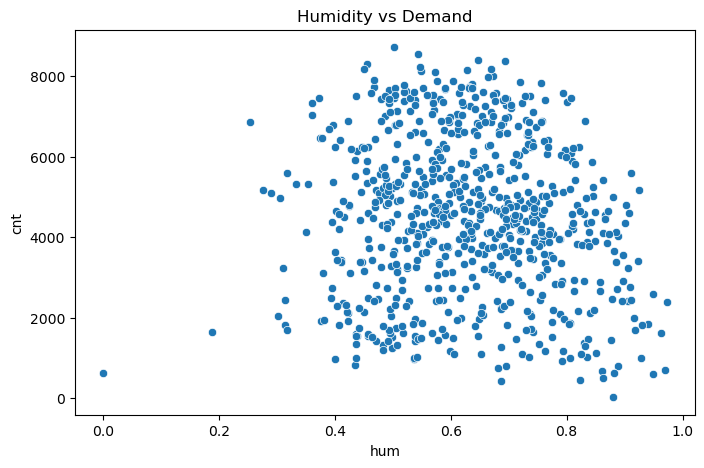

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='hum',
    y='cnt',
    data=df
)

plt.title('Humidity vs Demand')
plt.xlabel('hum')
plt.ylabel('cnt')

plt.show()

### Windspeed vs Demand

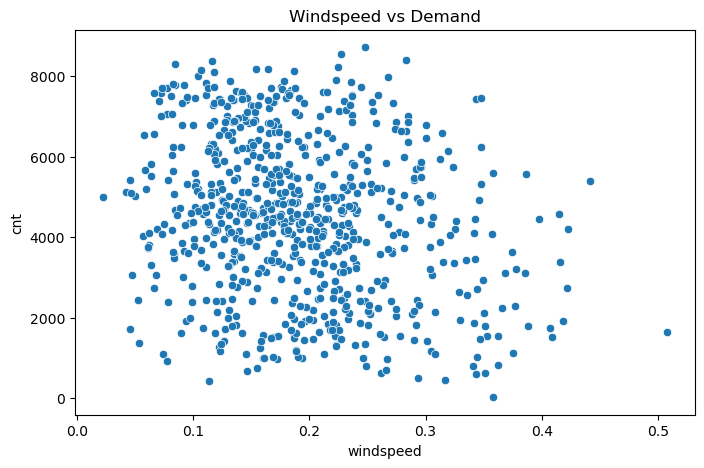

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='windspeed',
    y='cnt',
    data=df
)

plt.title('Windspeed vs Demand')
plt.xlabel('windspeed')
plt.ylabel('cnt')

plt.show()

## Correlation Matrix

                cnt      temp       hum  windspeed
cnt        1.000000  0.627494 -0.100659  -0.234545
temp       0.627494  1.000000  0.126963  -0.157944
hum       -0.100659  0.126963  1.000000  -0.248489
windspeed -0.234545 -0.157944 -0.248489   1.000000


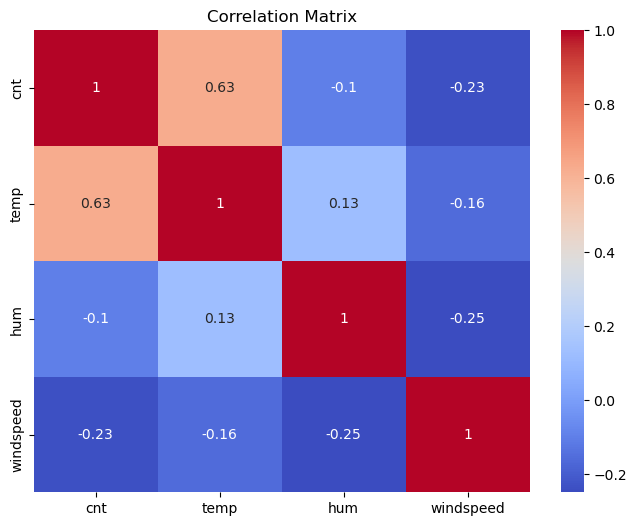

In [ ]:
corr_cols = [
    'cnt',
    'temp',
    'hum',
    'windspeed'
]

corr = df[corr_cols].corr()

print(corr)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

مقادیر نزدیک به +1 نشان‌دهنده رابطه مثبت قوی هستند.
مقادیر نزدیک به -1 نشان‌دهنده رابطه منفی قوی هستند.
مقادیر نزدیک به صفر نشان‌دهنده رابطه ضعیف هستند.

## Ranking of Important Features Based on EDA

بر اساس تحلیل‌های انجام‌شده در مرحله EDA، عوامل مؤثر بر تقاضای روزانه دوچرخه رتبه‌بندی شدند.

نتایج نشان داد که:

دمای هوا (temp) مهم‌ترین عامل مؤثر بر تقاضا است.
با افزایش دما، معمولاً تعداد اجاره‌ها افزایش پیدا می‌کند.

وضعیت آب‌وهوا (weathersit) تأثیر زیادی روی تقاضا دارد.
در شرایط آب‌وهوایی مناسب:

Weather 1 → حدود 4900 تقاضا
Weather 2 → حدود 4000 تقاضا
Weather 3 → حدود 1900 تقاضا

بنابراین شرایط نامناسب جوی باعث کاهش استفاده از دوچرخه می‌شود.

| Season Code | Season | Average Demand |
| ----------- | ------ | -------------- |
| 3           | Fall   | ~6000          |
| 2           | Summer | ~5000          |
| 4           | Winter | ~4500          |
| 1           | Spring | ~2900          |


رطوبت (hum) اثر متوسط و منفی دارد.
روز کاری (workingday) اختلاف زیادی ایجاد نکرده است.
سرعت باد (windspeed) کمترین اثر مشاهده‌شده را داشته است.


## ادامه

خواسته پی دی اف اصلی : 

 Mean cnt by:
   - season
   - workingday
   - weathersit

 Histograms + Comparison with Artificial Normal Distribution

14 Compare cnt distribution in 2011 and 2012

 Scatter Plots:
   - temp vs cnt
   - hum vs cnt
   - windspeed vs cnt

مادلینگ : 

| Model               | Feature(s) |
| ------------------- | ---------- |
| Linear Regression   | temp       |
| Polynomial Degree 2 | temp       |
| Polynomial Degree 3 | temp       |


## saving

### دیتا مرتب شده و تبدیل شده

In [ ]:
# Convert to datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# Sort by date
df_sorted = df.sort_values('dteday').reset_index(drop=True)

# Save as a new CSV file
df_sorted.to_csv('day_sorted.csv', index=False)

print("day_sorted.csv saved successfully")

day_sorted.csv saved successfully


### داده آماده برای مادلینگ

In [ ]:
df_model = df_sorted.drop(
    columns=['instant', 'casual', 'registered']
)

df_model.to_csv(
    'day_model.csv',
    index=False
)

print("day_model.csv saved successfully")

day_model.csv saved successfully
